# Deliverable 2: Fashion Parsing

## 1. Install and Import Dependencies

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import defaultdict

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')
print("All imports OK")

All imports OK


## 2. Configuration – Set Your Paths Here

In [2]:
# Path to the Fashionpedia TRAIN JSON annotation file
ANNO_JSON_PATH = "data/instances_attributes_train2020.json"

# Directory containing the PNG segmentation maps produced by fashionpedia.py
# Each file is named <image_stem>_seg.png
SEG_PNG_DIR = "data/segmentations_train/"

assert os.path.exists(ANNO_JSON_PATH), f"JSON not found: {ANNO_JSON_PATH}"
assert os.path.isdir(SEG_PNG_DIR),     f"Segmentation dir not found: {SEG_PNG_DIR}"
print(f"JSON : {ANNO_JSON_PATH}")
print(f"PNGs : {SEG_PNG_DIR}")

JSON : data/instances_attributes_train2020.json
PNGs : data/segmentations_train/


## 3. Load Annotations and Build Category Map

In [3]:
with open(ANNO_JSON_PATH, 'r') as f:
    annotation_data = json.load(f)

# category_id -> category_name  (IDs 0..45 in the JSON)
# In the segmentation PNGs, pixel_value = category_id + 1 (so 0 = background)
category_id_to_name = {category['id']: category['name'] for category in annotation_data['categories']}
category_ids   = sorted(category_id_to_name.keys())   # sorted label indices (0, 1, 2, ...)
category_names = [category_id_to_name[cid] for cid in category_ids]

# image_id -> image metadata
img_id_to_info = {img['id']: img for img in annotation_data['images']}

print(f"Number of categories : {len(category_ids)}")
print(f"Number of images     : {len(img_id_to_info)}")
print(f"Number of annotations: {len(annotation_data['annotations'])}")
print("\nCategory list (label index -> name):")
for category_id in category_ids:
    print(f"  [{category_id}] {category_id_to_name[category_id]}")

Number of categories : 46
Number of images     : 45623
Number of annotations: 333401

Category list (label index -> name):
  [0] shirt, blouse
  [1] top, t-shirt, sweatshirt
  [2] sweater
  [3] cardigan
  [4] jacket
  [5] vest
  [6] pants
  [7] shorts
  [8] skirt
  [9] coat
  [10] dress
  [11] jumpsuit
  [12] cape
  [13] glasses
  [14] hat
  [15] headband, head covering, hair accessory
  [16] tie
  [17] glove
  [18] watch
  [19] belt
  [20] leg warmer
  [21] tights, stockings
  [22] sock
  [23] shoe
  [24] bag, wallet
  [25] scarf
  [26] umbrella
  [27] hood
  [28] collar
  [29] lapel
  [30] epaulette
  [31] sleeve
  [32] pocket
  [33] neckline
  [34] buckle
  [35] zipper
  [36] applique
  [37] bead
  [38] bow
  [39] flower
  [40] fringe
  [41] ribbon
  [42] rivet
  [43] ruffle
  [44] sequin
  [45] tassel


## 4. Iterate Over PNG Segmentation Maps and Collect Statistics

Each PNG pixel value equals `category_id + 1` (0 = background, 1 = category 0, …, 46 = category 45).  
We read every segmentation PNG and accumulate per-label pixel counts.

In [4]:
def get_seg_png(img_info, seg_dir):
    img_stem = os.path.splitext(img_info['file_name'])[0]
    path = os.path.join(seg_dir, f"{img_stem}_seg.png")
    return path if os.path.exists(path) else None

In [5]:
per_label_data = {category_id: {'ratio_full': [], 'ratio_foreground': []} for category_id in category_ids}

for img_id, img_info in img_id_to_info.items():
    seg_path = get_seg_png(img_info, SEG_PNG_DIR)

    if seg_path is None:
        raise Exception("File not found.", img_info)

    # Load PNG (H, W, 1)
    seg = np.array(Image.open(seg_path))

    total_pixels = seg.size
    fg_pixels    = int((seg > 0).sum())   # foreground = any non-background pixel

    labels_present, counts = np.unique(seg, return_counts=True)

    for label, count in zip(labels_present.tolist(), counts.tolist()):
        # skip background
        if label == 0:
            continue    

        # fashionpedia.py stores category_id + 1
        cat_id = label - 1                

        per_label_data[cat_id]['ratio_full'].append(count / total_pixels)
        per_label_data[cat_id]['ratio_fg'].append(count / fg_pixels)



KeyError: 'ratio_fg'

## 5. Build Summary DataFrame

In [ ]:
rows = []
for category_id in category_ids:
    ratio_full = np.array(per_label_data[category_id]['ratio_full'])
    ratio_foreground = np.array(per_label_data[category_id]['ratio_foreground'])
    images_count  = len(ratio_full)
    rows.append({
        'category_id'    : category_id,
        'category_name'  : category_id_to_name[category_id],
        'num_images'     : images_count,
        'mean_ratio_full': float(ratio_full.mean()),
        'var_ratio_full' : float(ratio_full.var()),
        'mean_ratio_foreground'  : float(ratio_foreground.mean()),
        'var_ratio_foreground'   : float(ratio_foreground.var()),
    })

df = pd.DataFrame(rows)

fmt = lambda x: f"{x:.5f}" if pd.notna(x) else 'N/A'
print(df[['category_name','num_images','mean_ratio_full','var_ratio_full',
          'mean_ratio_foreground','var_ratio_foreground']].to_string(index=False, formatters={
    'mean_ratio_full': fmt, 'var_ratio_full': fmt,
    'mean_ratio_foreground'  : fmt, 'var_ratio_foreground'  : fmt,
}))

df.to_csv('label_distribution_stats.csv', index=False)
print("Saved -> label_distribution_stats.csv")

                          category_name  num_images mean_ratio_full var_ratio_full mean_ratio_foreground var_ratio_foreground
                          shirt, blouse        6084         0.06641        0.01027               0.24180              0.05675
               top, t-shirt, sweatshirt       16102         0.08892        0.01507               0.35085              0.07351
                                sweater        1480         0.15131        0.02084               0.42870              0.06006
                               cardigan        1101         0.10723        0.01914               0.32496              0.04716
                                 jacket        7741         0.07519        0.00630               0.29726              0.02025
                                   vest         717         0.05989        0.00731               0.26805              0.05108
                                  pants       12346         0.07040        0.00457               0.36489              

## 6. Plot: Number of Images per Label

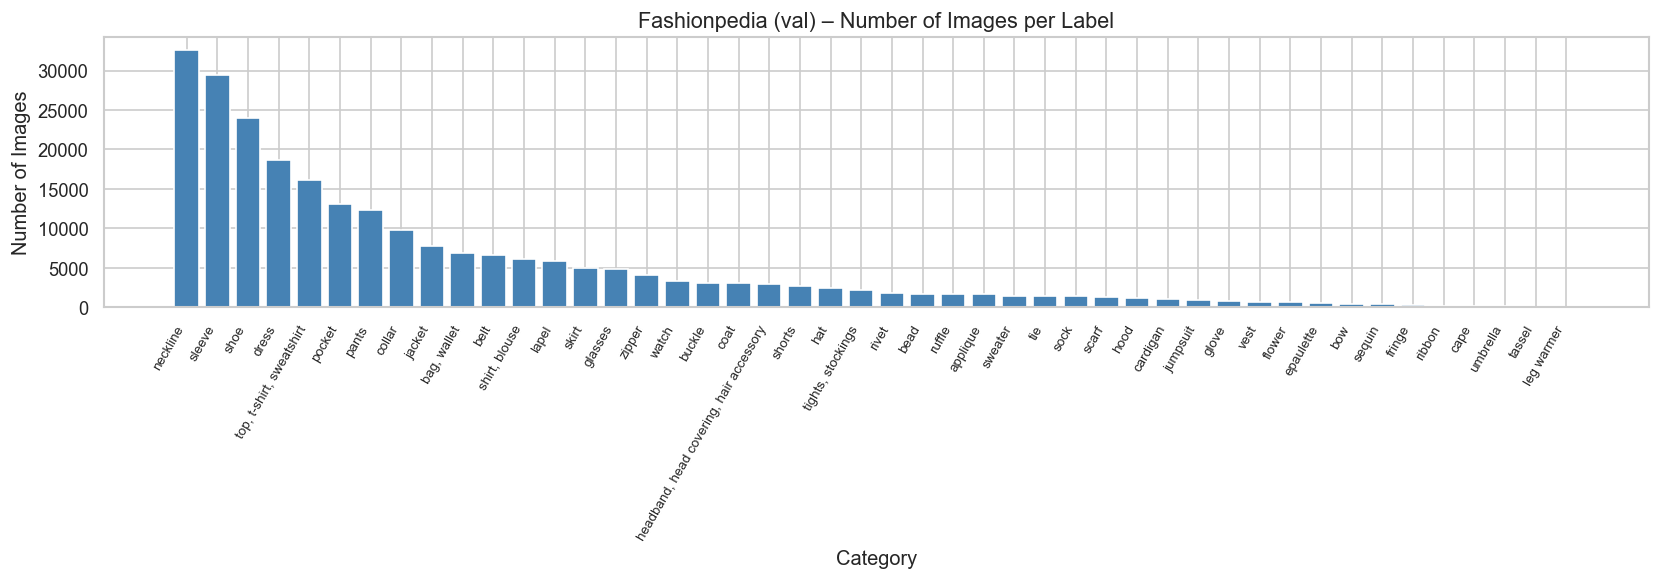

Saved -> plots/images_per_label.png


In [24]:
df_sorted_imgs = df.sort_values('num_images', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(df_sorted_imgs['category_name'], df_sorted_imgs['num_images'],
       color='steelblue', edgecolor='white')
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Fashionpedia (val) – Number of Images per Label', fontsize=13)
plt.xticks(rotation=60, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('plots/images_per_label.png', bbox_inches='tight')
plt.show()
print("Saved -> plots/images_per_label.png")

## 7. Plot: Pixel Ratio Statistics (ratio_full and ratio_fg)

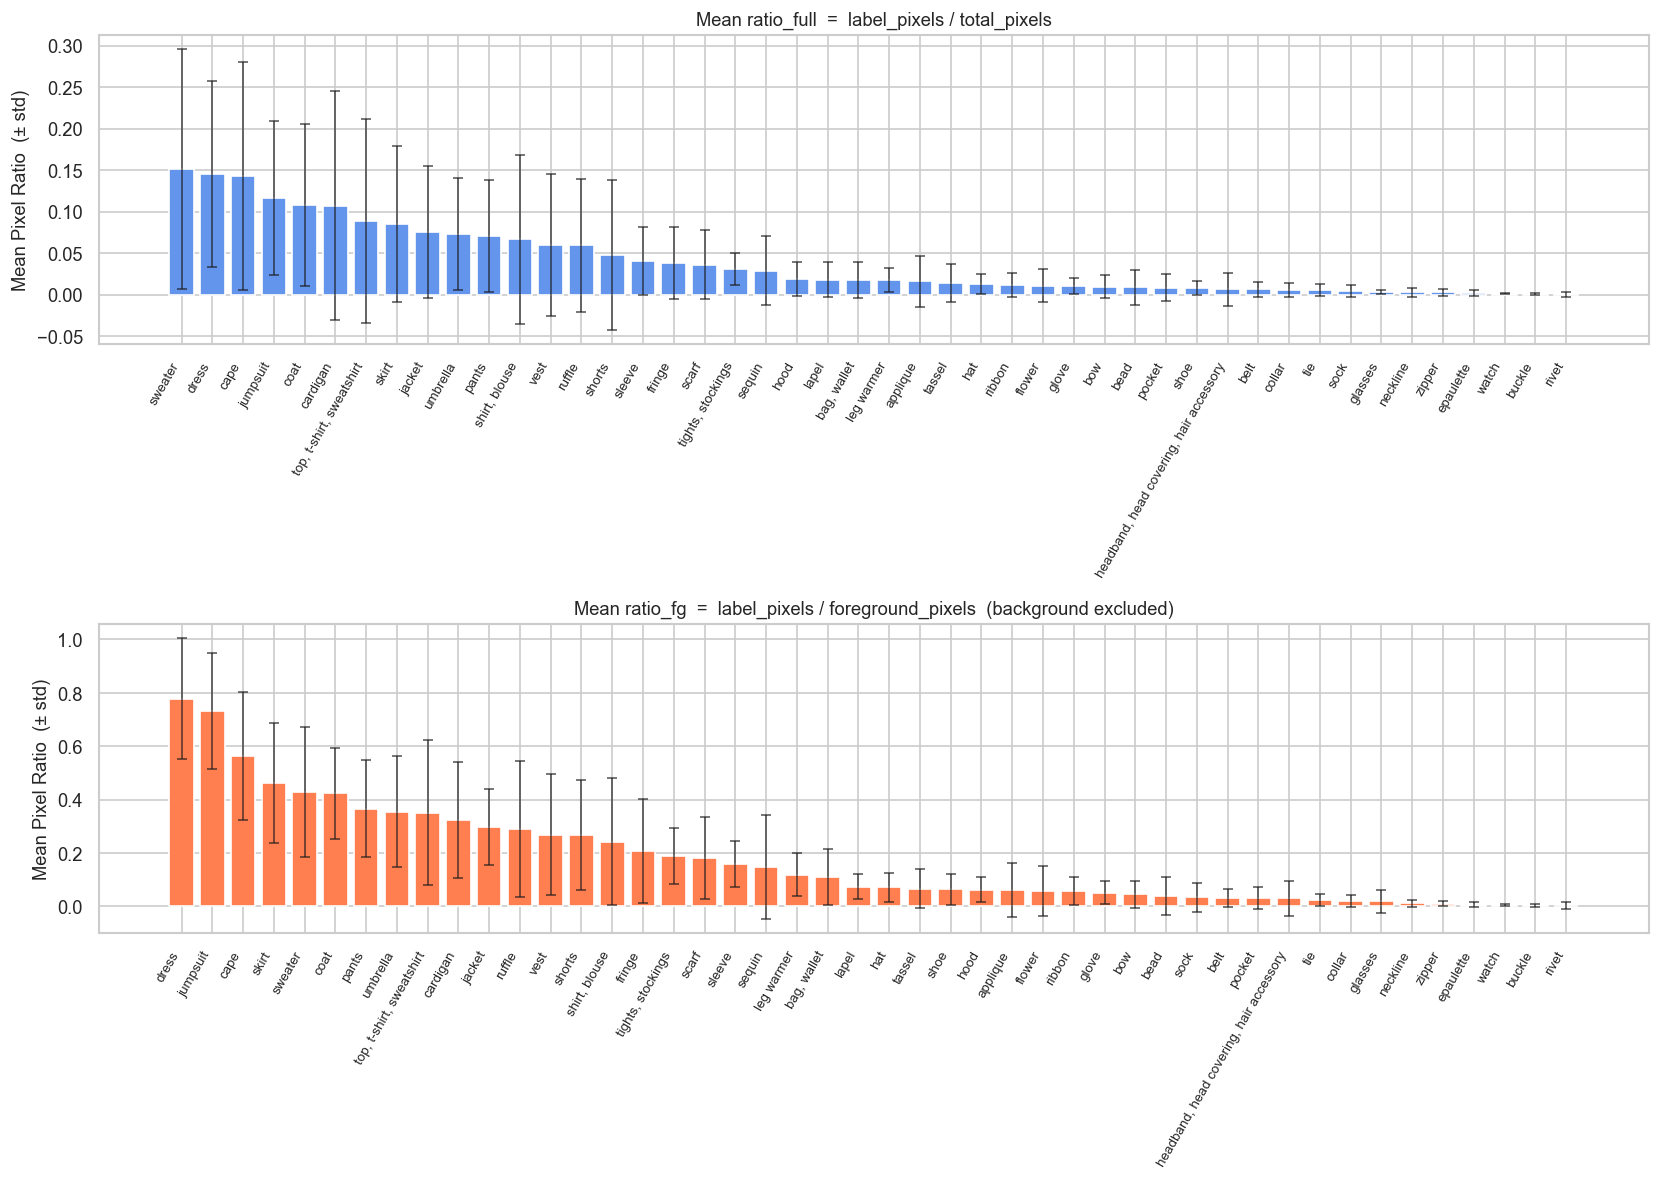

Saved -> plots/pixel_ratio_per_label.png


In [25]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ax, metric, color, title in [
    (axes[0], 'ratio_full', 'cornflowerblue',
     'Mean ratio_full  =  label_pixels / total_pixels'),
    (axes[1], 'ratio_foreground',   'coral',
     'Mean ratio_fg  =  label_pixels / foreground_pixels  (background excluded)'),
]:
    df_s  = df.sort_values(f'mean_{metric}', ascending=False)
    x     = np.arange(len(df_s))
    means = df_s[f'mean_{metric}'].values
    stds  = np.sqrt(df_s[f'var_{metric}'].values)

    ax.bar(x, means, yerr=stds, color=color, capsize=3,
           edgecolor='white', error_kw={'elinewidth': 1, 'alpha': 0.7})
    ax.set_xticks(x)
    ax.set_xticklabels(df_s['category_name'], rotation=60, ha='right', fontsize=8)
    ax.set_ylabel('Mean Pixel Ratio  (± std)', fontsize=11)
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.savefig('plots/pixel_ratio_per_label.png', bbox_inches='tight')
plt.show()
print("Saved -> plots/pixel_ratio_per_label.png")

## 8. Combined 3-Panel Summary

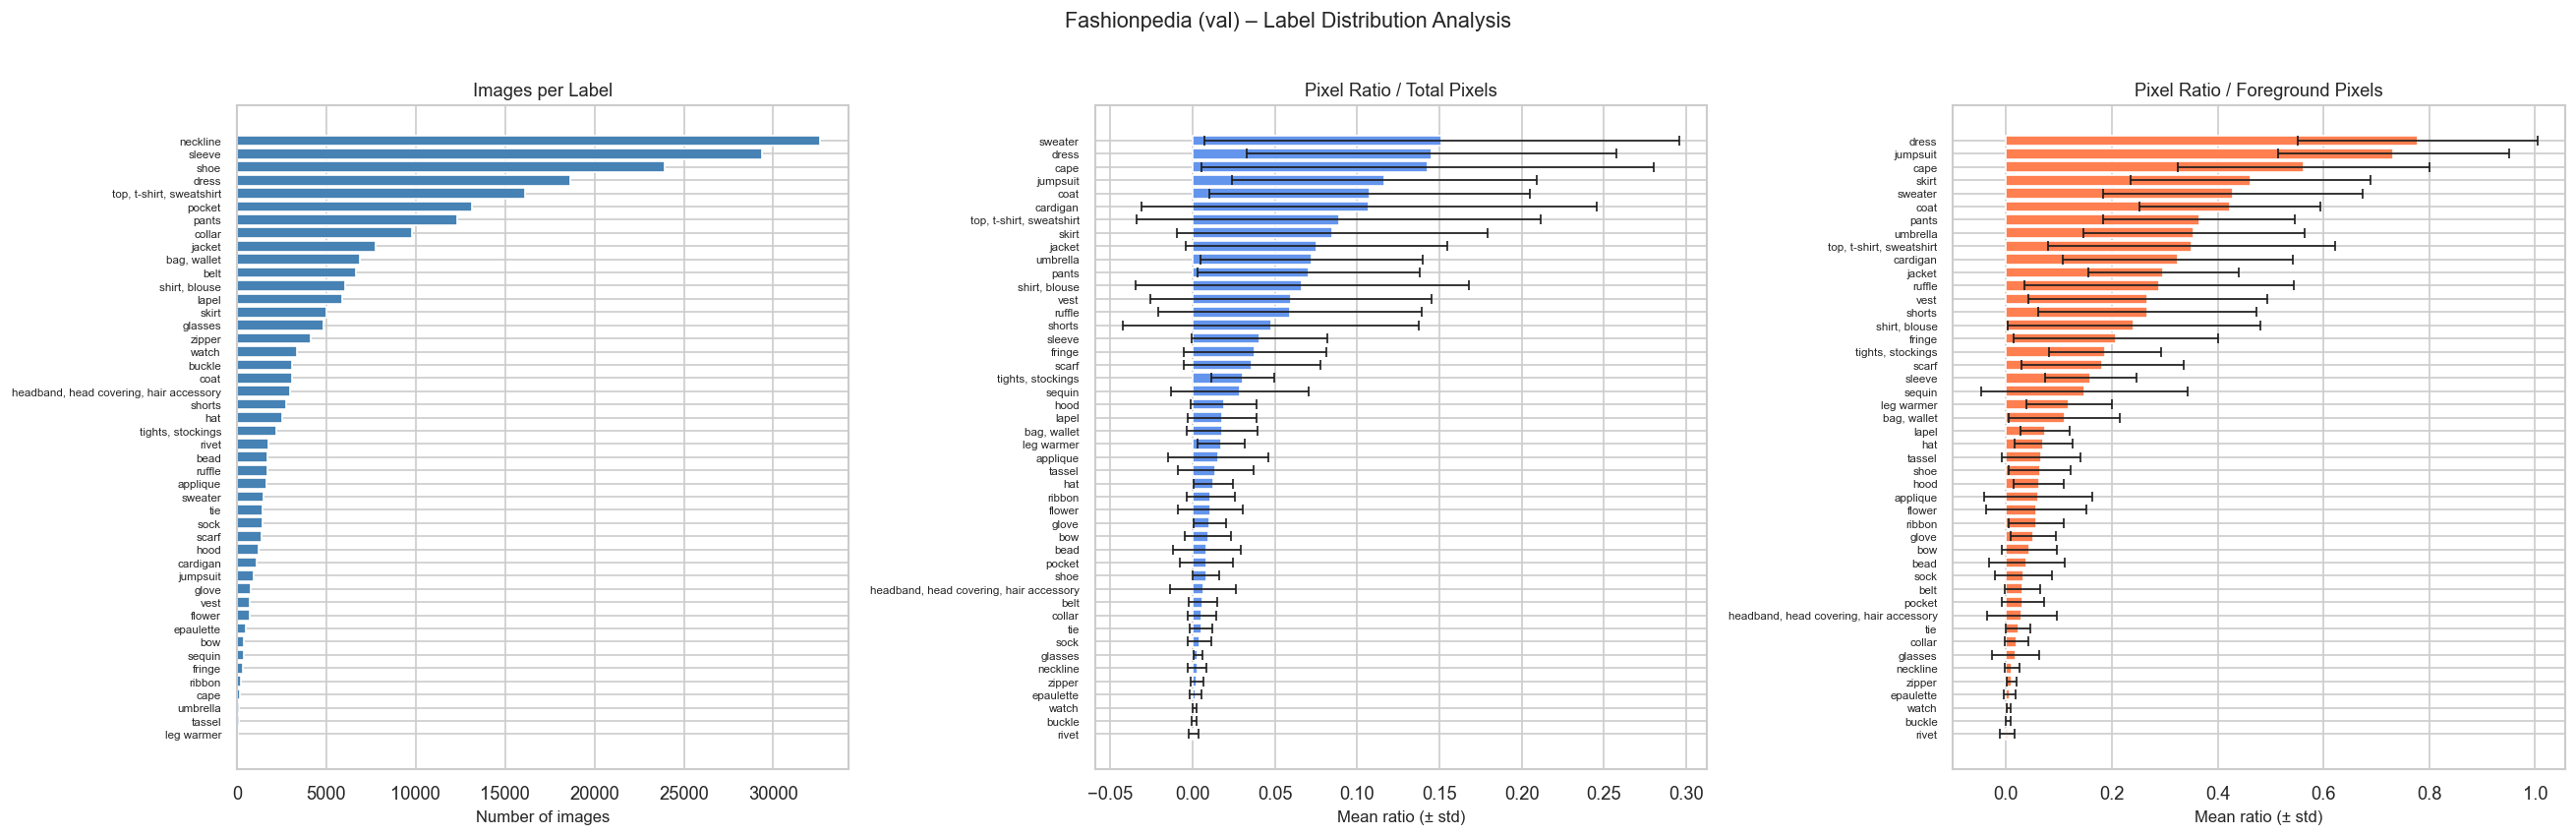

Saved -> plots/label_distribution_summary.png


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, sort_col, val_col, err_col, color, xlabel, title in [
    (axes[0], 'num_images',      'num_images',      None,
     'steelblue',      'Number of images',  'Images per Label'),
    (axes[1], 'mean_ratio_full', 'mean_ratio_full', 'var_ratio_full',
     'cornflowerblue', 'Mean ratio (± std)', 'Pixel Ratio / Total Pixels'),
    (axes[2], 'mean_ratio_foreground',   'mean_ratio_foreground',   'var_ratio_foreground',
     'coral',          'Mean ratio (± std)', 'Pixel Ratio / Foreground Pixels'),
]:
    df_s = df.sort_values(sort_col, ascending=False)
    vals = df_s[val_col].values
    errs = np.sqrt(df_s[err_col].values) if err_col else None

    ax.barh(df_s['category_name'], vals, xerr=errs,
            color=color, capsize=3, error_kw={'elinewidth': 1})
    ax.invert_yaxis()
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Fashionpedia (val) – Label Distribution Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('plots/label_distribution_summary.png', bbox_inches='tight')
plt.show()
print("Saved -> plots/label_distribution_summary.png")

## 9. Top-10 Most and Least Dominant Labels

In [22]:
df_valid = df.dropna(subset=['mean_ratio_full'])

print("Top-10 most dominant labels (mean ratio_full):")
print(df_valid.nlargest(10, 'mean_ratio_full')
      [['category_name','num_images','mean_ratio_full','var_ratio_full']]
      .to_string(index=False))

print("\nTop-10 least dominant labels (mean ratio_full):")
print(df_valid.nsmallest(10, 'mean_ratio_full')
      [['category_name','num_images','mean_ratio_full','var_ratio_full']]
      .to_string(index=False))

Top-10 most dominant labels (mean ratio_full):
           category_name  num_images  mean_ratio_full  var_ratio_full
                 sweater        1480         0.151314        0.020842
                   dress       18664         0.145040        0.012620
                    cape         152         0.142893        0.018943
                jumpsuit         922         0.116494        0.008549
                    coat        3084         0.107656        0.009497
                cardigan        1101         0.107231        0.019136
top, t-shirt, sweatshirt       16102         0.088920        0.015070
                   skirt        5029         0.085004        0.008927
                  jacket        7741         0.075195        0.006305
                umbrella         134         0.072486        0.004557

Top-10 least dominant labels (mean ratio_full):
category_name  num_images  mean_ratio_full  var_ratio_full
        rivet        1760         0.000490    8.987047e-06
       buckle   

## Task 2 - Semantic Segmentation

In this section we've the notebook with a the full semantic segmentation pipeline for Fashionpedia. The runs compare three segmentation architectures, augmentation and resolution effects, and then retrain the best setup after discarding labels that are large and overrepresented according to the statistics we found in task 1.

### 1. Setup

In [ ]:
# IF MISSING PACKAGES
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# %pip install albumentations torchmetrics segmentation-models-pytorch timm opencv-python matplotlib pandas seaborn pillow

import itertools
import os
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from torch.utils.data import DataLoader

from augmentations import build_transforms
from experiment_utils import (
    compare_per_class_runs,
    ensure_dir,
    load_results_table,
    select_overrepresented_labels,
    set_seed,
)
from model_factory import SUPPORTED_MODELS, build_model
from segmentation_dataset import (
    FashionSegmentationDataset,
    apply_label_remap_to_names,
    build_category_maps,
    get_train_val_records,
    make_reduced_label_remap,
    subset_records,
)
from train_eval import get_device, run_experiment

print("Task 2 imports loaded.")
print("Device:", get_device())
print("Supported models:", SUPPORTED_MODELS)


c:\Users\Daniel Hess\Documents\Master\OR\Fashion_Segmentation\.venv\lib\site-packages\albumentations\__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.24). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Task 2 imports loaded.
Device: cuda
Supported models: ('deeplabv3plus_resnet50', 'segformer_b0', 'upernet_swin_tiny')


### 2. Configuration and Global Settings

This cell centralizes paths, seeds, run modes, and search settings. Validation images are read from `data/test` by default, while all Task 2 artifacts are saved under `outputs/task2/`.


In [2]:
PROJECT_ROOT = Path(".")
TRAIN_JSON_PATH = PROJECT_ROOT / "data/instances_attributes_train2020.json"
VAL_JSON_PATH = PROJECT_ROOT / "data/instances_attributes_val2020.json"
TRAIN_IMAGE_DIR = PROJECT_ROOT / "data/train"
VAL_IMAGE_DIR = PROJECT_ROOT / "data/test"
OPTIONAL_VAL_IMAGE_DIR = PROJECT_ROOT / "data/validation"
TRAIN_MASK_DIR = PROJECT_ROOT / "data/segmentations_train"
VAL_MASK_DIR = PROJECT_ROOT / "data/segmentations_val"

OUTPUT_ROOT = ensure_dir(PROJECT_ROOT / "outputs/task2")
BACKGROUND_INDEX = 0
FULL_NUM_CLASSES = 47
SEED = 7
FORCE_RERUN = False

RUN_MODE = "full"  # choose from: smoke, pilot, full

MODE_DEFAULTS = {
    "smoke": {
        "epochs": 1,
        "train_subset": 32,
        "val_subset": 16,
        "max_train_batches": 2,
        "max_val_batches": 2,
        "early_stopping_patience": None,
    },
    "pilot": {
        "epochs": 2,
        "train_subset": 256,
        "val_subset": 64,
        "max_train_batches": None,
        "max_val_batches": None,
        "early_stopping_patience": 2,
    },
    "full": {
        "epochs": 12,
        "train_subset": None,
        "val_subset": None,
        "max_train_batches": None,
        "max_val_batches": None,
        "early_stopping_patience": 3,
    },
}

FOCUSED_GRID = {
    "model_name": [
        "deeplabv3plus_resnet50",
        "segformer_b0",
        "upernet_swin_tiny",
    ],
    "image_size": [192, 384],
    "learning_rate": [1e-3, 3e-4],
    "batch_size": [8, 16],
    "augmentation": ["weak", "strong"],
}

PILOT_CONFIGS = [
    {
        "model_name": "deeplabv3plus_resnet50",
        "image_size": 192,
        "learning_rate": 1e-3,
        "batch_size": 8,
        "augmentation": "weak",
    },
    {
        "model_name": "segformer_b0",
        "image_size": 384,
        "learning_rate": 3e-4,
        "batch_size": 8,
        "augmentation": "strong",
    },
    {
        "model_name": "upernet_swin_tiny",
        "image_size": 192,
        "learning_rate": 3e-4,
        "batch_size": 8,
        "augmentation": "weak",
    },
]

set_seed(SEED)
print("Run mode:", RUN_MODE)
print("Output root:", OUTPUT_ROOT)


Run mode: full
Output root: outputs\task2


### 3. Dataset Utilities

We build train and validation records directly from the Fashionpedia JSON files and pair each image with its semantic segmentation PNG. Masks keep the semantic format `0 = background` and `category_id + 1 = foreground class`.


In [3]:
category_id_to_name, semantic_id_to_name = build_category_maps(TRAIN_JSON_PATH)

if OPTIONAL_VAL_IMAGE_DIR.exists():
    active_val_image_dir = OPTIONAL_VAL_IMAGE_DIR
    print("Using optional validation image folder:", active_val_image_dir)
else:
    active_val_image_dir = VAL_IMAGE_DIR
    print("Using validation images from:", active_val_image_dir)
    print("Tip: run create_validation_only_folder.py if you want a dedicated validation image folder.")

train_records, val_records = get_train_val_records(
    train_json_path=TRAIN_JSON_PATH,
    val_json_path=VAL_JSON_PATH,
    train_image_dir=TRAIN_IMAGE_DIR,
    val_image_dir=active_val_image_dir,
    train_mask_dir=TRAIN_MASK_DIR,
    val_mask_dir=VAL_MASK_DIR,
)

print(f"Train records: {len(train_records):,}")
print(f"Validation records: {len(val_records):,}")
print("First semantic labels:", list(semantic_id_to_name.items())[:6])


Using validation images from: data\test
Tip: run create_validation_only_folder.py if you want a dedicated validation image folder.
Train records: 45,623
Validation records: 1,158
First semantic labels: [(0, 'background'), (1, 'shirt, blouse'), (2, 'top, t-shirt, sweatshirt'), (3, 'sweater'), (4, 'cardigan'), (5, 'jacket')]


Sample image tensor shape: torch.Size([3, 1024, 1024])
Sample mask tensor shape: torch.Size([1024, 1024])
Sample mask unique labels: [ 0  8 24]


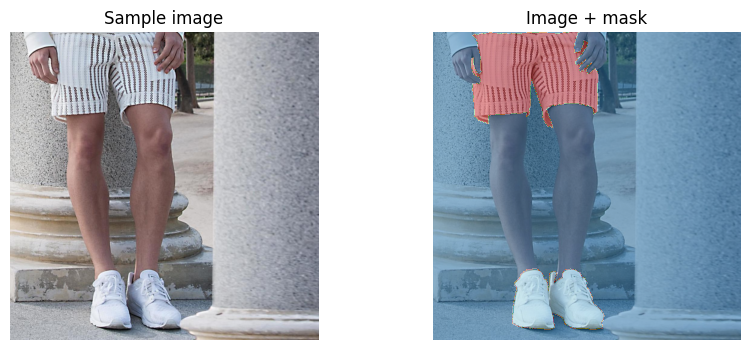

In [5]:
sample_dataset = FashionSegmentationDataset(
    records=subset_records(train_records, 1),
    transform=None,
    label_remap=None,
)
sample_item = sample_dataset[0]
image_np = np.transpose(sample_item["image"].numpy(), (1, 2, 0)).astype(np.uint8)
mask_np = sample_item["mask"].numpy()

print("Sample image tensor shape:", sample_item["image"].shape)
print("Sample mask tensor shape:", sample_item["mask"].shape)
print("Sample mask unique labels:", np.unique(mask_np)[:20])

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image_np)
plt.title("Sample image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image_np)
plt.imshow(mask_np, alpha=0.45, cmap="tab20")
plt.title("Image + mask")
plt.axis("off")
plt.show()


### 4. Augmentation Pipelines

Task 2 uses exactly two training presets, `weak` and `strong`, plus a deterministic validation transform. Albumentations applies the same geometric transform to both the image and the segmentation mask so the labels stay aligned.


In [6]:
weak_transform = build_transforms("weak", image_size=192)
strong_transform = build_transforms("strong", image_size=192)
val_transform = build_transforms("val", image_size=192)

transformed_sample = weak_transform(image=image_np, mask=mask_np)
print("Weak transform image shape:", transformed_sample["image"].shape)
print("Weak transform mask shape:", transformed_sample["mask"].shape)
print("Unique labels after transform:", torch.unique(transformed_sample["mask"])[:20].cpu().numpy())


Weak transform image shape: torch.Size([3, 192, 192])
Weak transform mask shape: torch.Size([192, 192])
Unique labels after transform: [ 0  8 24]


### 5. Model Factory

A single model factory keeps the rest of the notebook architecture-agnostic. This is helpful when we compare DeepLabV3+, SegFormer, and UPerNet using the same training and validation code.


In [7]:
model_parameter_rows = []
for model_name in SUPPORTED_MODELS:
    model = build_model(model_name, num_classes=FULL_NUM_CLASSES)
    parameter_count = sum(param.numel() for param in model.parameters())
    model_parameter_rows.append(
        {"model_name": model_name, "parameters_millions": parameter_count / 1e6}
    )
    del model

pd.DataFrame(model_parameter_rows)


c:\Users\Daniel Hess\Documents\Master\OR\Fashion_Segmentation\model_factory.py:70: RuntimeWarning: `image_size` was not provided for `upernet_swin_tiny`; defaulting to 224 for model construction. Pass 192 or 384 explicitly during experiments.
  warnings.warn(
c:\Users\Daniel Hess\Documents\Master\OR\Fashion_Segmentation\.venv\lib\site-packages\torch\functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


,model_name,parameters_millions
0,deeplabv3plus_resnet50,26.689407
1,segformer_b0,3.726223
2,upernet_swin_tiny,36.754921


### 6. Losses and Metrics

We train with multiclass cross-entropy and report validation metrics that exclude the background class from the main summary. Per-class Dice is still saved for every class so label-level behavior can be inspected later.


In [8]:
print("Background index:", BACKGROUND_INDEX)
print("Full number of classes:", FULL_NUM_CLASSES)
print("Headline metrics:")
print("- Pixel accuracy excluding background")
print("- Mean Dice excluding background")
print("- Per-class Dice")


Background index: 0
Full number of classes: 47
Headline metrics:
- Pixel accuracy excluding background
- Mean Dice excluding background
- Per-class Dice


### 7. Training and Validation Loops

The helper code handles mixed precision when CUDA is available, checkpointing by validation mDice excluding background, early stopping for pilot/full runs, and machine-readable experiment logging.


In [9]:
def make_mode_config(run_mode: str) -> dict:
    config = deepcopy(MODE_DEFAULTS[run_mode])
    config["run_mode"] = run_mode
    return config


def make_dataloaders(config, label_remap=None):
    train_subset = subset_records(train_records, config.get("train_subset"))
    val_subset = subset_records(val_records, config.get("val_subset"))

    train_dataset = FashionSegmentationDataset(
        records=train_subset,
        transform=build_transforms(config["augmentation"], config["image_size"]),
        label_remap=label_remap,
    )
    val_dataset = FashionSegmentationDataset(
        records=val_subset,
        transform=build_transforms("val", config["image_size"]),
        label_remap=label_remap,
    )

    batch_size = config["batch_size"]
    num_workers = 0 if get_device().type == "cpu" else min(4, os.cpu_count() or 2)
    loader_kwargs = {
        "batch_size": batch_size,
        "num_workers": num_workers,
        "pin_memory": get_device().type == "cuda",
    }
    train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
    val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
    return train_loader, val_loader


def finalize_config(base_config: dict, run_mode: str, num_classes: int, reduced_label_tag: str = "full_labels") -> dict:
    config = deepcopy(base_config)
    config.update(make_mode_config(run_mode))
    config["num_classes"] = num_classes
    config["background_index"] = BACKGROUND_INDEX
    config["force_rerun"] = FORCE_RERUN
    config["reduced_label_tag"] = reduced_label_tag
    config.setdefault("early_stopping_delta", 0.0)
    return config


print("Task 2 training helpers are ready.")


Task 2 training helpers are ready.


### 8. Experiment Configuration

The grid definition is separated from the core training code. This makes it easy to start with a smoke test, then run pilots, and finally scale to the full comparison.


In [9]:
def build_full_experiment_configs():
    configs = []
    for model_name, image_size, learning_rate, batch_size, augmentation in itertools.product(
        FOCUSED_GRID["model_name"],
        FOCUSED_GRID["image_size"],
        FOCUSED_GRID["learning_rate"],
        FOCUSED_GRID["batch_size"],
        FOCUSED_GRID["augmentation"],
    ):
        configs.append(
            {
                "model_name": model_name,
                "image_size": image_size,
                "learning_rate": learning_rate,
                "batch_size": batch_size,
                "augmentation": augmentation,
            }
        )
    return configs


SMOKE_CONFIG = {
    "model_name": "deeplabv3plus_resnet50",
    "image_size": 192,
    "learning_rate": 1e-3,
    "batch_size": 4,
    "augmentation": "weak",
}

print("Smoke config:", SMOKE_CONFIG)
print("Focused full grid size:", len(build_full_experiment_configs()))


Smoke config: {'model_name': 'deeplabv3plus_resnet50', 'image_size': 192, 'learning_rate': 0.001, 'batch_size': 4, 'augmentation': 'weak'}
Focused full grid size: 48


### 9. Smoke Test / Pilot Run

Run the smoke test first to validate the end-to-end pipeline. If it passes, the pilot runs provide a practical estimate of speed and memory before the full grid is launched.


In [10]:
smoke_config = finalize_config(
    base_config=SMOKE_CONFIG,
    run_mode="smoke",
    num_classes=FULL_NUM_CLASSES,
)
smoke_train_loader, smoke_val_loader = make_dataloaders(smoke_config)

smoke_batch = next(iter(smoke_train_loader))
print("Smoke batch image shape:", smoke_batch["image"].shape)
print("Smoke batch mask shape:", smoke_batch["mask"].shape)

smoke_model = build_model(smoke_config["model_name"], smoke_config["num_classes"]).to(get_device())
smoke_logits = smoke_model(smoke_batch["image"].to(get_device()))
print("Smoke forward output shape:", tuple(smoke_logits.shape))


Smoke batch image shape: torch.Size([4, 3, 192, 192])
Smoke batch mask shape: torch.Size([4, 192, 192])
Smoke forward output shape: (4, 47, 192, 192)


In [11]:
smoke_model = build_model(smoke_config["model_name"], smoke_config["num_classes"])
smoke_result = run_experiment(
    config=smoke_config,
    model=smoke_model,
    train_loader=smoke_train_loader,
    val_loader=smoke_val_loader,
    class_names=semantic_id_to_name,
    output_root=OUTPUT_ROOT,
)
smoke_result


c:\Users\Daniel Hess\Documents\Master\OR\Fashion_Segmentation\train_eval.py:189: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None


{'status': 'skipped_existing',
 'run_name': 'deeplabv3plus_resnet50_res192_lr0.001_bs4_weak_smoke_full_labels',
 'checkpoint_path': 'outputs\\task2\\checkpoints\\deeplabv3plus_resnet50_res192_lr0.001_bs4_weak_smoke_full_labels.pt'}

In [13]:
pilot_results = []
for pilot_base in PILOT_CONFIGS:
    pilot_config = finalize_config(
        base_config=pilot_base,
        run_mode="pilot",
        num_classes=FULL_NUM_CLASSES,
    )
    print(
        f"Running pilot: {pilot_config['model_name']} | "
        f"{pilot_config['image_size']} px | {pilot_config['augmentation']}"
    )
    pilot_train_loader, pilot_val_loader = make_dataloaders(pilot_config)
    pilot_model = build_model(
        pilot_config["model_name"],
        pilot_config["num_classes"],
        image_size=pilot_config["image_size"],
    )
    result = run_experiment(
        config=pilot_config,
        model=pilot_model,
        train_loader=pilot_train_loader,
        val_loader=pilot_val_loader,
        class_names=semantic_id_to_name,
        output_root=OUTPUT_ROOT,
    )
    pilot_results.append(result)

pd.DataFrame(pilot_results)


Running pilot: deeplabv3plus_resnet50 | 192 px | weak
Running pilot: segformer_b0 | 384 px | strong
Running pilot: upernet_swin_tiny | 192 px | weak


c:\Users\Daniel Hess\Documents\Master\OR\Fashion_Segmentation\.venv\lib\site-packages\timm\layers\interpolate.py:47: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen/native/BucketizationUtils.h:34.)
  idx_right = torch.bucketize(x, p)


,status,run_name,checkpoint_path,model_name,image_size,learning_rate,batch_size,augmentation,run_mode,reduced_label_tag,num_classes,epochs,best_epoch,best_val_mdice_ex_bg,best_val_pixel_acc_ex_bg,best_val_miou_ex_bg,seconds,history_csv,per_class_csv,config_json
0,skipped_existing,deeplabv3plus_resnet50_res192_lr0.001_bs8_weak...,outputs\task2\checkpoints\deeplabv3plus_resnet...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,skipped_existing,segformer_b0_res384_lr0.0003_bs8_strong_pilot_...,outputs\task2\checkpoints\segformer_b0_res384_...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,completed,upernet_swin_tiny_res192_lr0.0003_bs8_weak_pil...,outputs\task2\checkpoints\upernet_swin_tiny_re...,upernet_swin_tiny,192.0,0.0003,8.0,weak,pilot,full_labels,47.0,2.0,2.0,0.046196,0.429867,0.031081,26.419346,outputs\task2\histories\upernet_swin_tiny_res1...,outputs\task2\per_class_metrics\upernet_swin_t...,outputs\task2\configs\upernet_swin_tiny_res192...


### 10. Full Experiment Execution

Once the smoke and pilot runs look healthy, switch `RUN_MODE` to `full` and execute the grid below. Completed runs are skipped unless `FORCE_RERUN = True`, which keeps the notebook resume-friendly.


In [14]:
full_results = []
if RUN_MODE == "full":
    for base_config in build_full_experiment_configs():
        config = finalize_config(
            base_config=base_config,
            run_mode="full",
            num_classes=FULL_NUM_CLASSES,
        )

        print(
            f"Running full experiment: {config['model_name']} | "
            f"{config['image_size']} px | lr={config['learning_rate']} | "
            f"bs={config['batch_size']} | aug={config['augmentation']}"
        )

        try:
            train_loader, val_loader = make_dataloaders(config)
            model = build_model(config["model_name"], config["num_classes"])
            result = run_experiment(
                config=config,
                model=model,
                train_loader=train_loader,
                val_loader=val_loader,
                class_names=semantic_id_to_name,
                output_root=OUTPUT_ROOT,
            )
        except RuntimeError as exc:
            if "out of memory" in str(exc).lower():
                result = {
                    "status": "oom_skipped",
                    "model_name": config["model_name"],
                    "image_size": config["image_size"],
                    "learning_rate": config["learning_rate"],
                    "batch_size": config["batch_size"],
                    "augmentation": config["augmentation"],
                    "run_mode": config["run_mode"],
                }
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
            else:
                raise

        full_results.append(result)

    pd.DataFrame(full_results).head()
else:
    print("Set RUN_MODE = 'full' before executing this cell.")


Running full experiment: deeplabv3plus_resnet50 | 192 px | lr=0.001 | bs=8 | aug=weak
Running full experiment: deeplabv3plus_resnet50 | 192 px | lr=0.001 | bs=8 | aug=strong
Running full experiment: deeplabv3plus_resnet50 | 192 px | lr=0.001 | bs=16 | aug=weak
Running full experiment: deeplabv3plus_resnet50 | 192 px | lr=0.001 | bs=16 | aug=strong
Running full experiment: deeplabv3plus_resnet50 | 192 px | lr=0.0003 | bs=8 | aug=weak
Running full experiment: deeplabv3plus_resnet50 | 192 px | lr=0.0003 | bs=8 | aug=strong
Running full experiment: deeplabv3plus_resnet50 | 192 px | lr=0.0003 | bs=16 | aug=weak
Running full experiment: deeplabv3plus_resnet50 | 192 px | lr=0.0003 | bs=16 | aug=strong
Running full experiment: deeplabv3plus_resnet50 | 384 px | lr=0.001 | bs=8 | aug=weak
Running full experiment: deeplabv3plus_resnet50 | 384 px | lr=0.001 | bs=8 | aug=strong
Running full experiment: deeplabv3plus_resnet50 | 384 px | lr=0.001 | bs=16 | aug=weak
Running full experiment: deeplabv3p

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x0000013D33677D90>
Traceback (most recent call last):
  File "c:\Users\Daniel Hess\Documents\Master\OR\Fashion_Segmentation\.venv\lib\site-packages\torch\utils\data\dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "c:\Users\Daniel Hess\Documents\Master\OR\Fashion_Segmentation\.venv\lib\site-packages\torch\utils\data\dataloader.py", line 1562, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


Running full experiment: upernet_swin_tiny | 192 px | lr=0.0003 | bs=8 | aug=weak
Running full experiment: upernet_swin_tiny | 192 px | lr=0.0003 | bs=8 | aug=strong
Running full experiment: upernet_swin_tiny | 192 px | lr=0.0003 | bs=16 | aug=weak
Running full experiment: upernet_swin_tiny | 192 px | lr=0.0003 | bs=16 | aug=strong
Running full experiment: upernet_swin_tiny | 384 px | lr=0.001 | bs=8 | aug=weak
Running full experiment: upernet_swin_tiny | 384 px | lr=0.001 | bs=8 | aug=strong
Running full experiment: upernet_swin_tiny | 384 px | lr=0.001 | bs=16 | aug=weak
Running full experiment: upernet_swin_tiny | 384 px | lr=0.001 | bs=16 | aug=strong
Running full experiment: upernet_swin_tiny | 384 px | lr=0.0003 | bs=8 | aug=weak
Running full experiment: upernet_swin_tiny | 384 px | lr=0.0003 | bs=8 | aug=strong
Running full experiment: upernet_swin_tiny | 384 px | lr=0.0003 | bs=16 | aug=weak
Running full experiment: upernet_swin_tiny | 384 px | lr=0.0003 | bs=16 | aug=strong


### 11. Results Aggregation and Analysis

These cells load saved summaries, rank configurations, compare 192 px and 384 px, compare weak versus strong augmentation, and inspect the per-class Dice scores for the best validation runs.


In [10]:
results_df = load_results_table(OUTPUT_ROOT)
if results_df.empty:
    print("No completed runs found yet in", OUTPUT_ROOT)
else:
    display_columns = [
        "model_name",
        "image_size",
        "learning_rate",
        "batch_size",
        "augmentation",
        "run_mode",
        "best_val_mdice_ex_bg",
        "best_val_pixel_acc_ex_bg",
        "seconds",
    ]
    display(results_df.sort_values("best_val_mdice_ex_bg", ascending=False)[display_columns].head(15))


,model_name,image_size,learning_rate,batch_size,augmentation,run_mode,best_val_mdice_ex_bg,best_val_pixel_acc_ex_bg,seconds
50,upernet_swin_tiny,384,0.0003,16,weak,full,0.362518,0.711979,12361.143780
18,deeplabv3plus_resnet50,384,0.0003,16,weak,full,0.350476,0.707204,5502.939495
19,deeplabv3plus_resnet50,384,0.0003,16,strong,full,0.340329,0.714956,5503.239986
51,upernet_swin_tiny,384,0.0003,16,strong,full,0.339942,0.696150,12357.466675
48,upernet_swin_tiny,384,0.0003,8,weak,full,0.339700,0.704457,11635.112982
16,deeplabv3plus_resnet50,384,0.0003,8,weak,full,0.335148,0.692090,5584.022442
34,segformer_b0,384,0.0003,16,weak,full,0.321270,0.694571,4558.235166
35,segformer_b0,384,0.0003,16,strong,full,0.316570,0.694057,4580.205909
17,deeplabv3plus_resnet50,384,0.0003,8,strong,full,0.311946,0.703291,5585.503516
32,segformer_b0,384,0.0003,8,weak,full,0.304444,0.673645,4507.412540


,model_name,image_size,mean_mdice,mean_pixel_acc
0,deeplabv3plus_resnet50,192,0.181310,0.517500
1,deeplabv3plus_resnet50,384,0.299662,0.675787
2,segformer_b0,192,0.201397,0.586834
3,segformer_b0,384,0.246982,0.616055
4,upernet_swin_tiny,192,0.222731,0.594768
5,upernet_swin_tiny,384,0.271549,0.632601


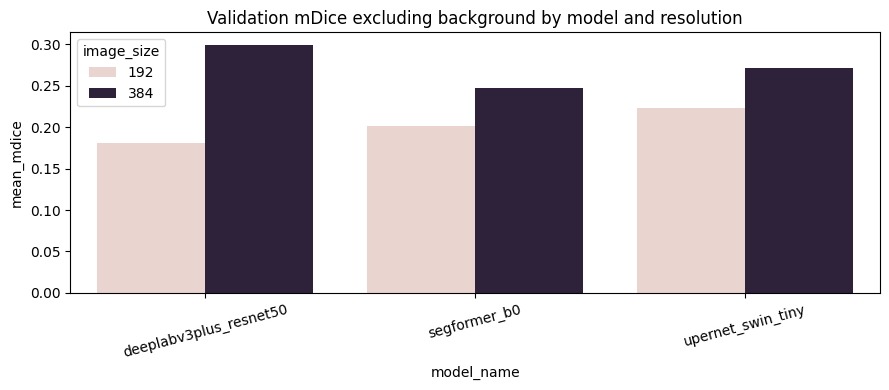

In [11]:
if not results_df.empty:
    resolution_summary = (
        results_df.groupby(["model_name", "image_size"], as_index=False)
        .agg(
            mean_mdice=("best_val_mdice_ex_bg", "mean"),
            mean_pixel_acc=("best_val_pixel_acc_ex_bg", "mean"),
        )
        .sort_values(["model_name", "image_size"])
    )
    display(resolution_summary)

    plt.figure(figsize=(9, 4))
    sns.barplot(data=resolution_summary, x="model_name", y="mean_mdice", hue="image_size")
    plt.xticks(rotation=15)
    plt.title("Validation mDice excluding background by model and resolution")
    plt.tight_layout()
    plt.show()


In [12]:
if not results_df.empty:
    augmentation_summary = (
        results_df.groupby(["model_name", "augmentation"], as_index=False)
        .agg(mean_mdice=("best_val_mdice_ex_bg", "mean"))
        .sort_values(["model_name", "augmentation"])
    )
    display(augmentation_summary)


,model_name,augmentation,mean_mdice
0,deeplabv3plus_resnet50,strong,0.252894
1,deeplabv3plus_resnet50,weak,0.218725
2,segformer_b0,strong,0.205289
3,segformer_b0,weak,0.248301
4,upernet_swin_tiny,strong,0.238129
5,upernet_swin_tiny,weak,0.252437


In [13]:
best_row = None
best_per_class_df = None

if not results_df.empty:
    best_row = results_df.sort_values("best_val_mdice_ex_bg", ascending=False).iloc[0]
    print("Best configuration:")
    display(best_row.to_frame().T)

    best_per_class_df = pd.read_csv(best_row["per_class_csv"])
    display(
        best_per_class_df[best_per_class_df["is_background"] == False]
        .sort_values("dice", ascending=False)
        .head(15)
    )


Best configuration:


,run_name,status,model_name,image_size,learning_rate,batch_size,augmentation,run_mode,reduced_label_tag,num_classes,epochs,best_epoch,best_val_mdice_ex_bg,best_val_pixel_acc_ex_bg,best_val_miou_ex_bg,seconds,checkpoint_path,history_csv,per_class_csv,config_json
50,upernet_swin_tiny_res384_lr0.0003_bs16_weak_fu...,completed,upernet_swin_tiny,384,0.0003,16,weak,full,full_labels,47,12,12,0.362518,0.711979,0.260529,12361.14378,outputs\task2\checkpoints\upernet_swin_tiny_re...,outputs\task2\histories\upernet_swin_tiny_res3...,outputs\task2\per_class_metrics\upernet_swin_t...,outputs\task2\configs\upernet_swin_tiny_res384...


,class_index,class_name,dice,iou,support,is_background
27,27,umbrella,0.904154,0.825074,88384.0,False
7,7,pants,0.827454,0.705690,2674313.0,False
11,11,dress,0.825376,0.702672,7949950.0,False
32,32,sleeve,0.817429,0.691230,2658035.0,False
24,24,shoe,0.746845,0.595972,854045.0,False
14,14,glasses,0.741930,0.589737,53391.0,False
2,2,"top, t-shirt, sweatshirt",0.711403,0.552076,2653946.0,False
22,22,"tights, stockings",0.700635,0.539213,274162.0,False
8,8,shorts,0.690806,0.527657,381684.0,False
15,15,hat,0.673904,0.508186,134737.0,False


### 12. Recover The Best Full-Label Checkpoint

The saved Task 2 summary table still tells us which full-label experiment performed best, even though the actual checkpoint file is gone. The following cell recreates only that single best run when needed so the reduced-label experiment can finetune from it instead of starting from scratch.


In [14]:
best_checkpoint_row = None
recovered_best_result = None

if results_df.empty:
    print("Run the aggregation section first so Task 2 results are available.")
else:
    full_label_results_df = results_df[
        (results_df["run_mode"] == "full")
        & (results_df["reduced_label_tag"] == "full_labels")
        & (results_df["status"] == "completed")
    ].copy()

    if full_label_results_df.empty:
        print("No completed full-label runs were found in outputs/task2/run_summary.csv")
    else:
        best_checkpoint_row = full_label_results_df.sort_values(
            "best_val_mdice_ex_bg", ascending=False
        ).iloc[0]
        print("Best full-label configuration for checkpoint recovery:")
        display(best_checkpoint_row.to_frame().T)

        checkpoint_path = Path(best_checkpoint_row["checkpoint_path"])
        if checkpoint_path.exists():
            print(f"Checkpoint already available: {checkpoint_path}")
            recovered_best_result = best_checkpoint_row.to_dict()
        else:
            print(f"Checkpoint missing, recreating only this run: {checkpoint_path}")
            recovery_base_config = {
                "model_name": best_checkpoint_row["model_name"],
                "image_size": int(best_checkpoint_row["image_size"]),
                "learning_rate": float(best_checkpoint_row["learning_rate"]),
                "batch_size": int(best_checkpoint_row["batch_size"]),
                "augmentation": best_checkpoint_row["augmentation"],
            }
            recovery_config = finalize_config(
                base_config=recovery_base_config,
                run_mode="full",
                num_classes=FULL_NUM_CLASSES,
                reduced_label_tag="full_labels",
            )
            recovery_config["force_rerun"] = True

            recovery_train_loader, recovery_val_loader = make_dataloaders(recovery_config)
            recovery_model = build_model(
                recovery_config["model_name"],
                recovery_config["num_classes"],
                image_size=recovery_config["image_size"],
            )
            recovered_best_result = run_experiment(
                config=recovery_config,
                model=recovery_model,
                train_loader=recovery_train_loader,
                val_loader=recovery_val_loader,
                class_names=semantic_id_to_name,
                output_root=OUTPUT_ROOT,
            )
            display(pd.DataFrame([recovered_best_result]))

        if recovered_best_result is not None:
            best_row = pd.Series(recovered_best_result)
            best_per_class_df = pd.read_csv(best_row["per_class_csv"])


Best full-label configuration for checkpoint recovery:


,run_name,status,model_name,image_size,learning_rate,batch_size,augmentation,run_mode,reduced_label_tag,num_classes,epochs,best_epoch,best_val_mdice_ex_bg,best_val_pixel_acc_ex_bg,best_val_miou_ex_bg,seconds,checkpoint_path,history_csv,per_class_csv,config_json
50,upernet_swin_tiny_res384_lr0.0003_bs16_weak_fu...,completed,upernet_swin_tiny,384,0.0003,16,weak,full,full_labels,47,12,12,0.362518,0.711979,0.260529,12361.14378,outputs\task2\checkpoints\upernet_swin_tiny_re...,outputs\task2\histories\upernet_swin_tiny_res3...,outputs\task2\per_class_metrics\upernet_swin_t...,outputs\task2\configs\upernet_swin_tiny_res384...


Checkpoint missing, recreating only this run: outputs\task2\checkpoints\upernet_swin_tiny_res384_lr0.0003_bs16_weak_full_full_labels.pt


c:\Users\Daniel Hess\Documents\Master\OR\Fashion_Segmentation\train_eval.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None
c:\Users\Daniel Hess\Documents\Master\OR\Fashion_Segmentation\train_eval.py:100: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


,run_name,status,model_name,image_size,learning_rate,batch_size,augmentation,run_mode,reduced_label_tag,num_classes,epochs,best_epoch,best_val_mdice_ex_bg,best_val_pixel_acc_ex_bg,best_val_miou_ex_bg,seconds,checkpoint_path,history_csv,per_class_csv,config_json
0,upernet_swin_tiny_res384_lr0.0003_bs16_weak_fu...,completed,upernet_swin_tiny,384,0.0003,16,weak,full,full_labels,47,12,12,0.364228,0.730514,0.261492,12353.363988,outputs\task2\checkpoints\upernet_swin_tiny_re...,outputs\task2\histories\upernet_swin_tiny_res3...,outputs\task2\per_class_metrics\upernet_swin_t...,outputs\task2\configs\upernet_swin_tiny_res384...


### 13. Reduced-Label Finetuning

The assignment also asks whether the remaining labels benefit if large and overrepresented classes are removed. We reuse Task 1 statistics, define a reduced label subset using a combined frequency-plus-dominance score, then finetune the best recovered full-label checkpoint on the reduced label set with the same hyperparameters.


In [15]:
if "df" in globals():
    task1_stats_df = df.copy()
    print("Using Task 1 dataframe already present in memory.")
else:
    task1_stats_df = pd.read_csv("label_distribution_stats.csv")
    print("Loaded Task 1 statistics from label_distribution_stats.csv")

reduced_label_stats = select_overrepresented_labels(task1_stats_df, rule="ratio_freq_combo")
dropped_labels_df = reduced_label_stats[reduced_label_stats["drop_for_reduced_label_run"]].copy()
kept_labels_df = reduced_label_stats[~reduced_label_stats["drop_for_reduced_label_run"]].copy()

print("Dropped labels for the reduced-label experiment:")
display(dropped_labels_df[["category_id", "category_name", "num_images", "mean_ratio_full", "overrep_score"]])
print("Retained labels:", len(kept_labels_df))


Loaded Task 1 statistics from label_distribution_stats.csv
Dropped labels for the reduced-label experiment:


,category_id,category_name,num_images,mean_ratio_full,overrep_score
0,10,dress,18664,0.145040,0.765146
1,31,sleeve,29397,0.040418,0.583287
2,1,"top, t-shirt, sweatshirt",16102,0.088920,0.539720
3,2,sweater,1480,0.151314,0.521811
4,33,neckline,32590,0.002724,0.507406
5,12,cape,152,0.142893,0.473480
6,6,pants,12346,0.070397,0.420581


Retained labels: 39


In [16]:
keep_semantic_ids = kept_labels_df["semantic_id"].tolist()
reduced_label_remap = make_reduced_label_remap(keep_semantic_ids, background_index=BACKGROUND_INDEX)
reduced_semantic_names = apply_label_remap_to_names(
    semantic_id_to_name,
    reduced_label_remap,
    background_index=BACKGROUND_INDEX,
)
reduced_num_classes = max(reduced_label_remap.values()) + 1

print("Reduced number of classes:", reduced_num_classes)
print("Example reduced label mapping:", list(reduced_label_remap.items())[:12])


Reduced number of classes: 40
Example reduced label mapping: [(0, 0), (1, 1), (4, 2), (5, 3), (6, 4), (8, 5), (9, 6), (10, 7), (12, 8), (14, 9), (15, 10), (16, 11)]


In [17]:
def load_matching_checkpoint_weights(model, checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    checkpoint_state = checkpoint["model_state_dict"]
    target_state = model.state_dict()

    compatible_state = {
        key: value
        for key, value in checkpoint_state.items()
        if key in target_state and tuple(value.shape) == tuple(target_state[key].shape)
    }
    skipped_keys = sorted(set(checkpoint_state.keys()) - set(compatible_state.keys()))
    missing_keys = sorted(set(target_state.keys()) - set(compatible_state.keys()))
    model.load_state_dict(compatible_state, strict=False)
    return checkpoint, skipped_keys, missing_keys


reduced_result = None
reduced_comparison_df = None

if best_row is None:
    print("Run the aggregation and checkpoint recovery sections first so the best checkpoint is available.")
else:
    checkpoint_path = Path(best_row["checkpoint_path"])
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Recovered best checkpoint still missing: {checkpoint_path}")

    reduced_base_config = {
        "model_name": best_row["model_name"],
        "image_size": int(best_row["image_size"]),
        "learning_rate": float(best_row["learning_rate"]),
        "batch_size": int(best_row["batch_size"]),
        "augmentation": best_row["augmentation"],
    }
    reduced_config = finalize_config(
        base_config=reduced_base_config,
        run_mode="full" if RUN_MODE == "full" else "pilot",
        num_classes=reduced_num_classes,
        reduced_label_tag="reduced_labels",
    )
    reduced_config["source_checkpoint"] = str(checkpoint_path)

    reduced_train_loader, reduced_val_loader = make_dataloaders(
        reduced_config,
        label_remap=reduced_label_remap,
    )
    reduced_model = build_model(
        reduced_config["model_name"],
        reduced_config["num_classes"],
        image_size=reduced_config["image_size"],
    )
    _, skipped_keys, missing_keys = load_matching_checkpoint_weights(
        reduced_model,
        checkpoint_path,
    )
    print(f"Finetuning from checkpoint: {checkpoint_path}")
    print(f"Skipped checkpoint keys due to shape mismatch: {len(skipped_keys)}")
    print(f"Target model keys initialized from scratch: {len(missing_keys)}")

    reduced_result = run_experiment(
        config=reduced_config,
        model=reduced_model,
        train_loader=reduced_train_loader,
        val_loader=reduced_val_loader,
        class_names=reduced_semantic_names,
        output_root=OUTPUT_ROOT / "reduced_labels",
    )
    display(pd.DataFrame([reduced_result]))

    if "per_class_csv" in reduced_result:
        baseline_per_class = pd.read_csv(best_row["per_class_csv"])
        reduced_per_class = pd.read_csv(reduced_result["per_class_csv"])
        reduced_comparison_df = compare_per_class_runs(
            baseline_df=baseline_per_class[baseline_per_class["is_background"] == False],
            reduced_df=reduced_per_class[reduced_per_class["is_background"] == False],
        )
        display(reduced_comparison_df.head(20))


C:\Users\Daniel Hess\AppData\Local\Temp\ipykernel_24152\3857650779.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=

Finetuning from checkpoint: outputs\task2\checkpoints\upernet_swin_tiny_res384_lr0.0003_bs16_weak_full_full_labels.pt
Skipped checkpoint keys due to shape mismatch: 2
Target model keys initialized from scratch: 2


c:\Users\Daniel Hess\Documents\Master\OR\Fashion_Segmentation\train_eval.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None
c:\Users\Daniel Hess\Documents\Master\OR\Fashion_Segmentation\train_eval.py:100: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


,run_name,status,model_name,image_size,learning_rate,batch_size,augmentation,run_mode,reduced_label_tag,num_classes,epochs,best_epoch,best_val_mdice_ex_bg,best_val_pixel_acc_ex_bg,best_val_miou_ex_bg,seconds,checkpoint_path,history_csv,per_class_csv,config_json
0,upernet_swin_tiny_res384_lr0.0003_bs16_weak_fu...,completed,upernet_swin_tiny,384,0.0003,16,weak,full,reduced_labels,40,12,4,0.325502,0.551495,0.229395,7148.555991,outputs\task2\reduced_labels\checkpoints\upern...,outputs\task2\reduced_labels\histories\upernet...,outputs\task2\reduced_labels\per_class_metrics...,outputs\task2\reduced_labels\configs\upernet_s...


,class_name,baseline_dice,reduced_dice,dice_delta
0,"headband, head covering, hair accessory",0.161893,0.297177,0.135284
1,scarf,0.311341,0.437925,0.126584
2,cardigan,0.093418,0.218704,0.125286
3,umbrella,0.805817,0.913713,0.107896
4,hat,0.592195,0.698658,0.106463
5,sock,0.327351,0.395558,0.068207
6,lapel,0.508327,0.565058,0.056731
7,ruffle,0.296280,0.345173,0.048893
8,jumpsuit,0.281366,0.328546,0.047180
9,glove,0.252283,0.294947,0.042664


### 14. Qualitative Predictions

Scalar metrics are useful, but segmentation quality is easier to interpret with visual examples. The following helper reloads the best checkpoint and shows validation predictions next to their ground-truth masks.


C:\Users\Daniel Hess\AppData\Local\Temp\ipykernel_24152\2791102553.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(result_row["checkpoint_path"],

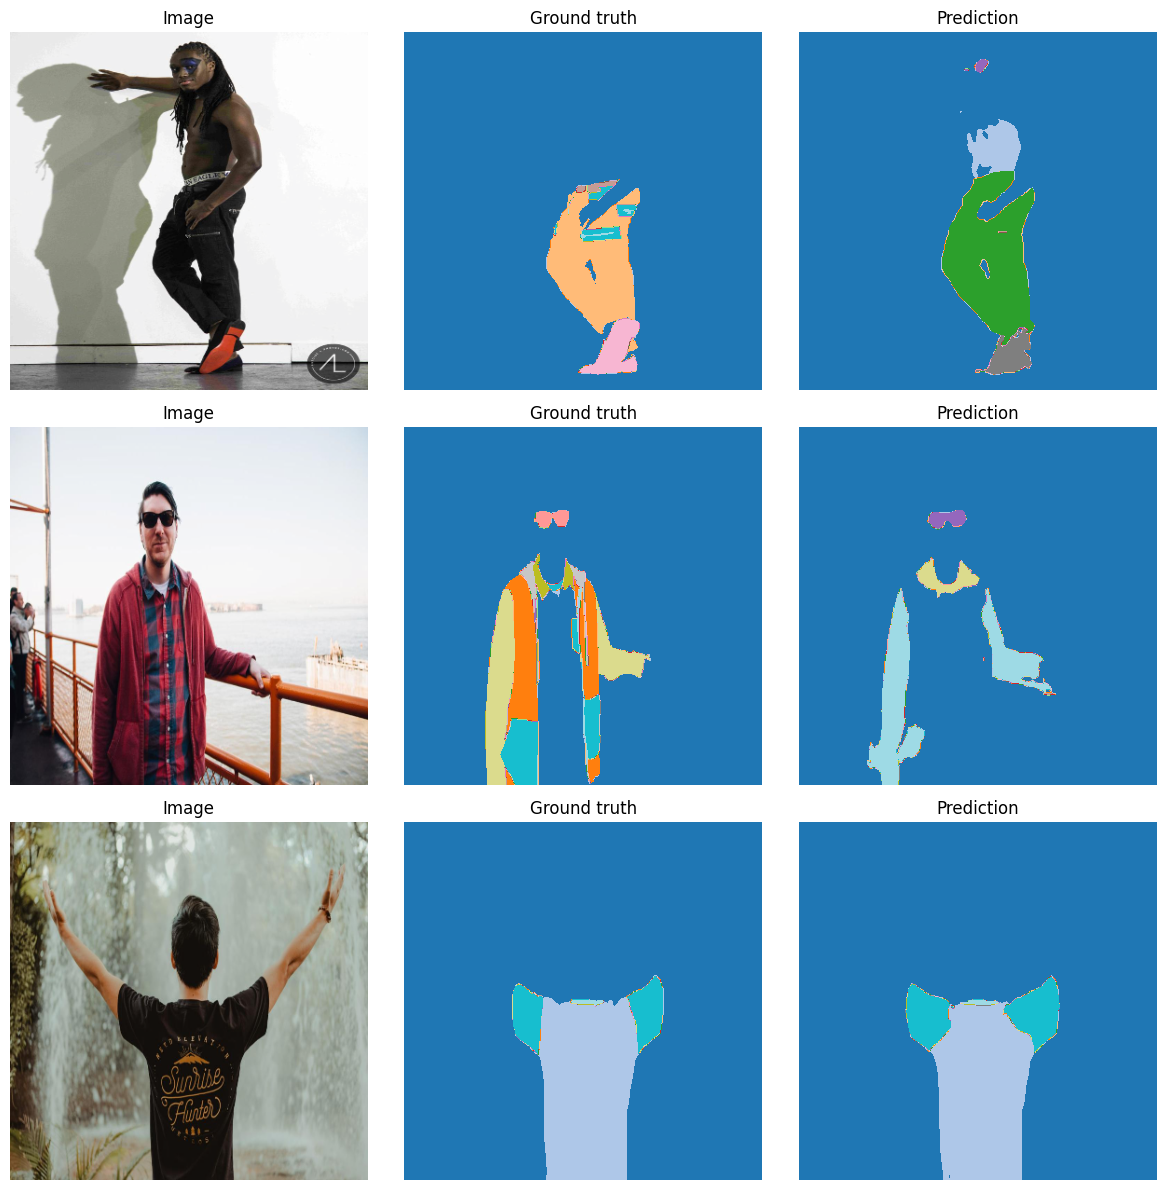

In [18]:
def load_checkpoint_model(result_row, num_classes):
    checkpoint = torch.load(result_row["checkpoint_path"], map_location=get_device())
    model = build_model( result_row["model_name"],
        num_classes=num_classes,
        image_size=int(result_row["image_size"]),)
    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(get_device())
    model.eval()
    return model


def show_predictions(result_row, records, label_remap=None, num_examples=3):
    num_classes = int(result_row.get("num_classes", FULL_NUM_CLASSES))
    model = load_checkpoint_model(result_row, num_classes=num_classes)
    dataset = FashionSegmentationDataset(
        records=subset_records(records, num_examples),
        transform=build_transforms("val", int(result_row["image_size"])),
        label_remap=label_remap,
    )

    fig, axes = plt.subplots(num_examples, 3, figsize=(12, 4 * num_examples))
    if num_examples == 1:
        axes = np.expand_dims(axes, axis=0)

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    for row_idx in range(num_examples):
        sample = dataset[row_idx]
        image_tensor = sample["image"].unsqueeze(0).to(get_device())
        mask = sample["mask"].cpu().numpy()

        with torch.no_grad():
            pred = model(image_tensor).argmax(dim=1).squeeze(0).detach().cpu().numpy()

        image_np = sample["image"].permute(1, 2, 0).cpu().numpy()
        image_np = np.clip(image_np * std + mean, 0.0, 1.0)

        axes[row_idx, 0].imshow(image_np)
        axes[row_idx, 0].set_title("Image")
        axes[row_idx, 1].imshow(mask, cmap="tab20")
        axes[row_idx, 1].set_title("Ground truth")
        axes[row_idx, 2].imshow(pred, cmap="tab20")
        axes[row_idx, 2].set_title("Prediction")
        for col_idx in range(3):
            axes[row_idx, col_idx].axis("off")

    plt.tight_layout()
    plt.show()


if best_row is not None:
    qualitative_row = best_row.to_dict()
    qualitative_row["num_classes"] = FULL_NUM_CLASSES
    show_predictions(qualitative_row, val_records, label_remap=None, num_examples=3)


### 15. Conclusions for Task 2

The strongest overall full-label configuration on the validation set was `upernet_swin_tiny` at `384 px` with `learning_rate = 3e-4`, `batch_size = 16`, and `weak` augmentation. This run achieved a validation `mDice excluding background` of approximately `0.364` and a `pixel accuracy excluding background` of approximately `0.712`, which was the best result in the full experiment table.

Resolution had a clear effect on performance. Across all three architectures, `384 px` consistently outperformed `192 px` on average, and the best individual runs for DeepLabV3+, SegFormer, and UPerNet all occurred at `384 px`. This suggests that the finer spatial detail available at the higher resolution was beneficial for Fashionpedia semantic segmentation, especially for smaller garment regions and boundary-heavy labels.

The augmentation comparison was more model-dependent than the resolution comparison, but `weak` augmentation was generally the safer choice for the best-performing runs. The winning configuration used `weak` augmentation, and for both SegFormer and UPerNet the average `mDice` was higher with `weak` augmentation than with `strong` augmentation. DeepLabV3+ was somewhat more robust and had a slightly stronger average under `strong` augmentation, but its best single run still remained below the best UPerNet result.

For the reduced-label study, the notebook now finetunes the recovered best full-label checkpoint instead of retraining a reduced model from scratch. Using the same architecture and hyperparameters, the reduced-label finetune reached a validation `mDice excluding background` of approximately `0.326`. This is still below the best full-label score, but it is noticeably stronger than the earlier reduced-label retraining result and gives a fairer answer to the assignment question because it isolates the effect of removing dominant labels while reusing the best learned representation.

The retained-label comparison shows a mixed outcome rather than a uniform gain. Several retained categories improved after finetuning on the reduced label set, especially `headband, head covering, hair accessory`, `scarf`, `cardigan`, `umbrella`, and `hat`, while others such as `tie`, `vest`, `pocket`, `skirt`, and `collar` declined. Overall, the reduced-label finetune remains a useful targeted analysis for specific labels, but it does not outperform the original best full-label model as a global semantic segmentation solution.

